In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data_processed/master_test_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win,Australia,Australia,South Africa
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win,Australia,Australia,South Africa
2,1000855,Australia,South Africa,Adelaide Oval,Adelaide,2016-11-24,Australia,NaN,7.0,2016,Win,Australia,Australia,South Africa
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win,Australia,Australia,Pakistan
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,Melbourne,2016-12-26,Australia,18.0,NaN,2016,Win,Australia,Australia,Pakistan


In [4]:
country = "India"

start_year = 2015
end_year = 2025

df_country = df[
    (df["team1"] == country) | (df["team2"] == country)
].copy()

df_country = df_country[
    (df_country["year"] >= start_year) &
    (df_country["year"] <= end_year)
]

In [5]:
df_country["opponent"] = df_country.apply(
    lambda row: row["team2"] if row["team1"] == country else row["team1"],
    axis=1
)

In [6]:
df_country[["team1", "team2", "opponent"]].head()

,team1,team2,opponent
13,West Indies,India,West Indies
14,West Indies,India,West Indies
15,West Indies,India,West Indies
16,West Indies,India,West Indies
21,India,New Zealand,New Zealand


In [7]:
def get_result(row):
    if pd.isna(row["winner"]):
        return "Draw"
    elif row["winner"] == country:
        return "Win"
    else:
        return "Loss"

df_country["result"] = df_country.apply(get_result, axis=1)

In [8]:
def get_location(row):
    if row["home_team"] == country:
        return "Home"
    elif row["away_team"] == country:
        return "Away"
    else:
        return "Neutral"

df_country["location"] = df_country.apply(get_location, axis=1)

In [9]:
opponent_summary = pd.pivot_table(
    df_country,
    values="match_id",
    index="opponent",
    columns="result",
    aggfunc="count",
    fill_value=0
)

opponent_summary

result,Draw,Loss,Win
opponent,,,
Australia,6,8,9
Bangladesh,1,0,7
England,3,10,16
New Zealand,1,6,4
South Africa,1,7,9
Sri Lanka,2,1,8
West Indies,3,0,9


In [10]:
opponent_summary["Total"] = (
    opponent_summary["Win"] +
    opponent_summary["Draw"] +
    opponent_summary["Loss"]
)

opponent_summary["Win_Percentage"] = (
    opponent_summary["Win"] / opponent_summary["Total"]
) * 100

opponent_summary = opponent_summary.sort_values(
    by="Win_Percentage",
    ascending=False
)

opponent_summary

result,Draw,Loss,Win,Total,Win_Percentage
opponent,,,,,
Bangladesh,1,0,7,8,87.500000
West Indies,3,0,9,12,75.000000
Sri Lanka,2,1,8,11,72.727273
England,3,10,16,29,55.172414
South Africa,1,7,9,17,52.941176
Australia,6,8,9,23,39.130435
New Zealand,1,6,4,11,36.363636


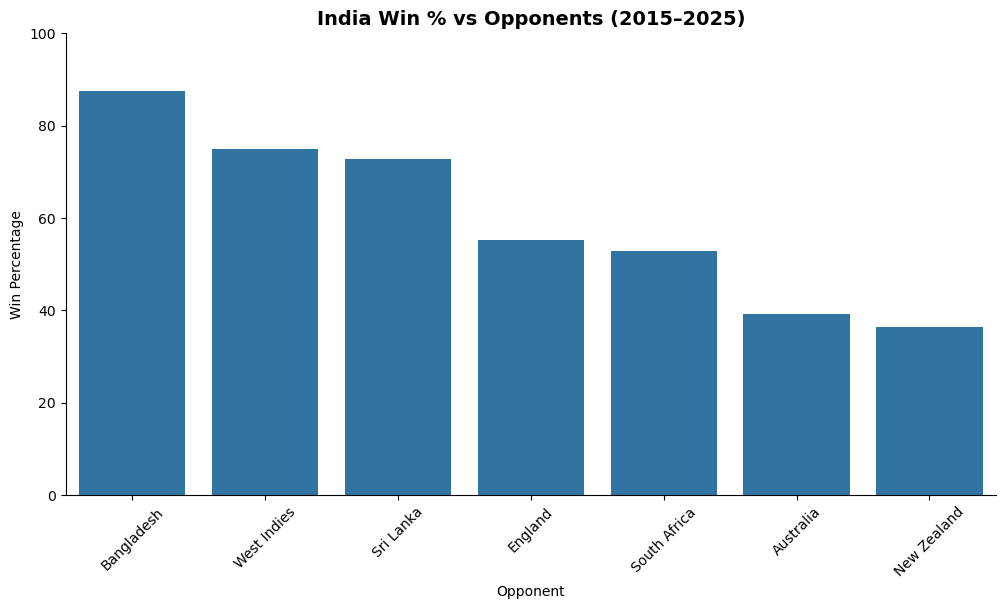

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=opponent_summary.reset_index(),
    x="opponent",
    y="Win_Percentage"
)
sns.despine()
plt.title(f"{country} Win % vs Opponents (2015–2025)",
          fontsize=14, fontweight='bold')

plt.xlabel("Opponent")
plt.ylabel("Win Percentage")
plt.ylim(0, 100)
plt.xticks(rotation=45)

plt.show()

“India remains dominant against weaker opponents, but struggles persist against stronger SENA nations, particularly Australia and New Zealand.”

In [22]:
summary = df_country.groupby(
    ["opponent", "location", "result"]
)["match_id"].count().reset_index()


pivot = summary.pivot_table(
    index=["opponent", "location"],
    columns="result",
    values="match_id",
    fill_value=0
).reset_index()

pivot["Total"] = (
    pivot["Win"] +
    pivot["Draw"] +
    pivot["Loss"]
)

pivot["Win_Percentage"] = (
    pivot["Win"] / pivot["Total"]
) * 100

pivot

result,opponent,location,Draw,Loss,Win,Total,Win_Percentage
0,Australia,Away,4.0,5.0,5.0,14.0,35.714286
1,Australia,Home,2.0,2.0,4.0,8.0,50.000000
2,Australia,Neutral,0.0,1.0,0.0,1.0,0.000000
3,Bangladesh,Away,1.0,0.0,2.0,3.0,66.666667
4,Bangladesh,Home,0.0,0.0,5.0,5.0,100.000000
5,England,Away,2.0,8.0,5.0,15.0,33.333333
6,England,Home,1.0,2.0,11.0,14.0,78.571429
7,New Zealand,Away,0.0,2.0,0.0,2.0,0.000000
8,New Zealand,Home,1.0,3.0,4.0,8.0,50.000000
9,New Zealand,Neutral,0.0,1.0,0.0,1.0,0.000000


In [20]:
plot_df = pivot.pivot(
    index="opponent",
    columns="location",
    values="Win_Percentage"
).reset_index()

plot_df

location,opponent,Away,Home,Neutral
0,Australia,35.714286,50.000000,0.0
1,Bangladesh,66.666667,100.000000,NaN
2,England,33.333333,78.571429,NaN
3,New Zealand,0.000000,50.000000,0.0
4,South Africa,37.500000,66.666667,NaN
5,Sri Lanka,83.333333,60.000000,NaN
6,West Indies,62.500000,100.000000,NaN


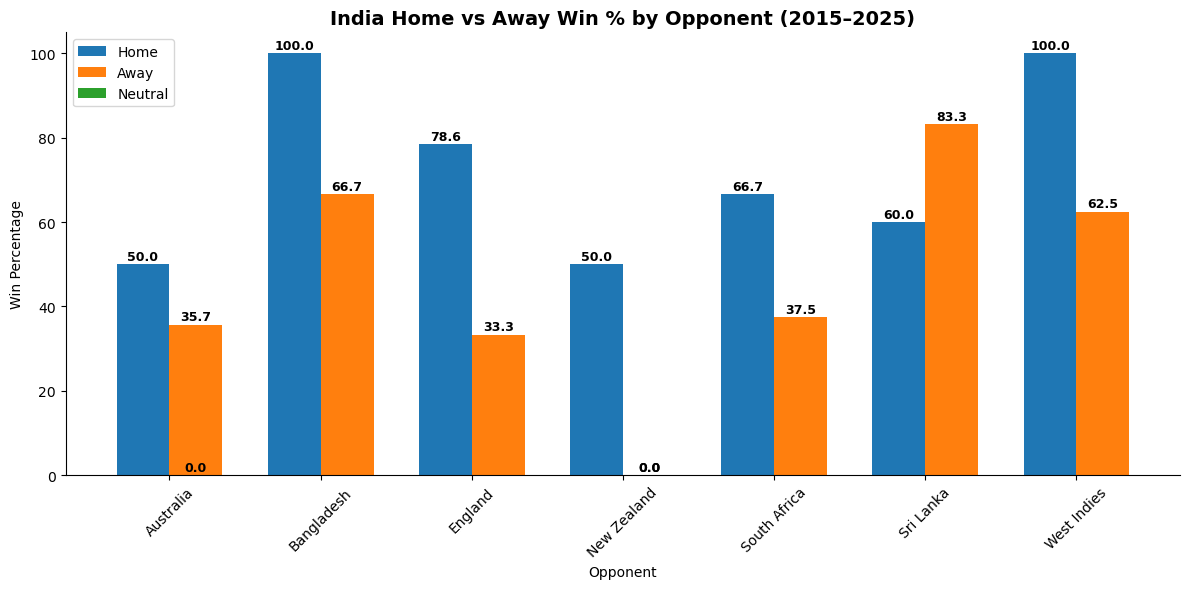

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x = np.arange(len(plot_df["opponent"]))
width = 0.35


fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(
    x - width/2,
    plot_df["Home"],
    width,
    label="Home"
)

bars2 = ax.bar(
    x + width/2,
    plot_df["Away"],
    width,
    label="Away"
)

bars3 = ax.bar(
    x + width/2,
    plot_df["Neutral"],
    width,
    label="Neutral"
)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha='center',
            fontsize=9,
            fontweight = 'bold'
        )

sns.despine()

# Labels
ax.set_title(
    f"{country} Home vs Away Win % by Opponent (2015–2025)",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("Opponent")
ax.set_ylabel("Win Percentage")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["opponent"], rotation=45)

ax.legend()

plt.tight_layout()
plt.show()

“India maintains strong home dominance and subcontinental superiority, but continues to face major challenges in overseas SENA conditions.”